# Module 4: Overlap Processing & the Short-Time Fourier Transform (STFT)

## The Time-Varying Signal Problem

Real signals don't sit still. A lightning strike builds, peaks, and decays. Music flows through verses and choruses. Your heartbeat speeds up when you exercise. The FFT gives you a static snapshot, but life is a movie.

The Short-Time Fourier Transform (STFT) is how we analyze signals that change over time. It creates a **spectrogram** - a heat map showing how frequency content evolves. This module teaches you:

* Why stationary analysis fails for real signals
* How to slice signals into overlapping frames
* The three-way trade-off: time vs frequency vs computational cost
* How to create and interpret spectrograms
* Advanced techniques for optimal STFT parameters

By the end, you'll be able to track how any signal changes through time.

## Part 1: Stationary vs Non-Stationary Signals

### The Stationarity Assumption

A **stationary** signal has statistical properties that don't change over time. The FFT assumes perfect stationarity - it treats your entire signal as one repeating cycle. This works for:
* Pure tones
* White noise
* Steady-state machinery vibration

But most real signals are **non-stationary**:
* Speech (phonemes change every ~50ms)
* Music (notes, beats, dynamics)
* Natural phenomena (lightning, earthquakes, heartbeats)
* Communications (data packets, frequency hopping)

Let's see why a single FFT fails for non-stationary signals:

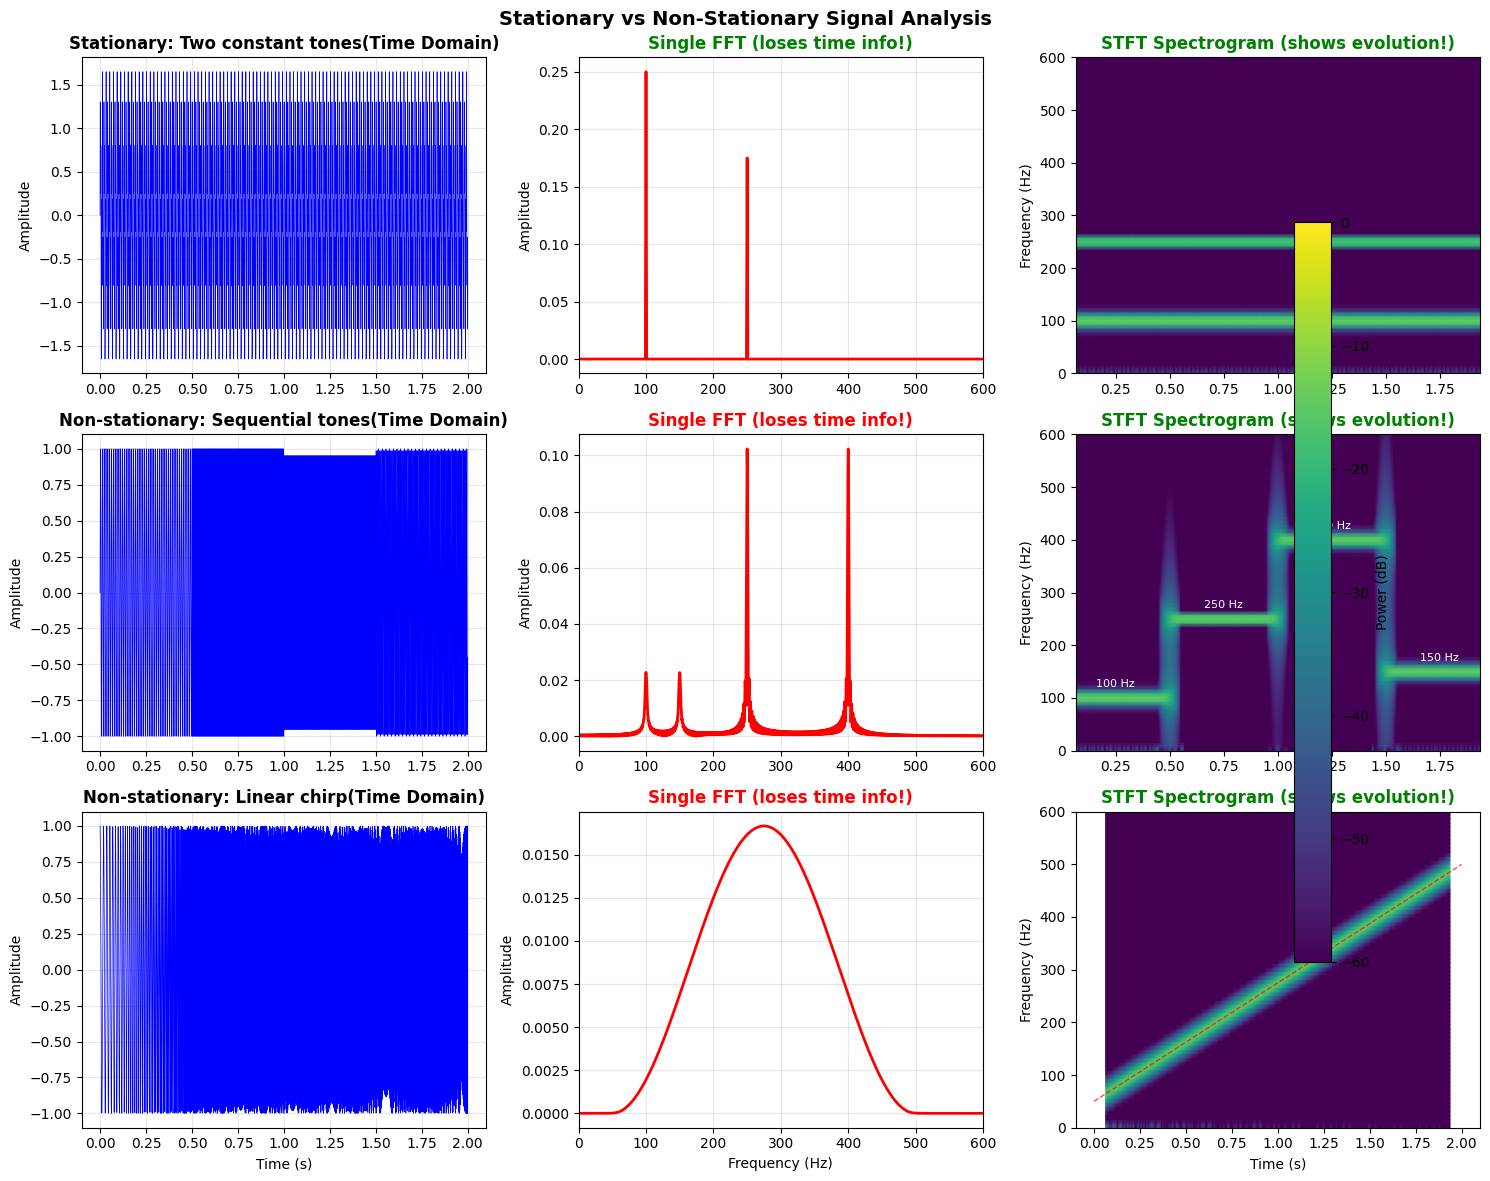

Key Observations:
1. Stationary signal: FFT tells the complete story
2. Sequential tones: FFT shows all frequencies but loses WHEN they occur
3. Chirp: FFT shows broad spectrum but misses the sweep pattern
→ STFT/Spectrogram reveals the time-frequency structure!


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
import warnings
warnings.filterwarnings('ignore')

def stationarity_comparison():
    """Compare FFT analysis of stationary vs non-stationary signals."""
    
    fs = 2000  # Sample rate
    duration = 2.0
    t = np.arange(0, duration, 1/fs)
    
    # Create three signals
    # 1. Stationary: constant frequencies
    stationary = (np.sin(2 * np.pi * 100 * t) + 
                 0.7 * np.sin(2 * np.pi * 250 * t))
    
    # 2. Non-stationary: sequential tones
    sequential = np.zeros_like(t)
    sequential[t < 0.5] = np.sin(2 * np.pi * 100 * t[t < 0.5])
    sequential[(t >= 0.5) & (t < 1.0)] = np.sin(2 * np.pi * 250 * t[(t >= 0.5) & (t < 1.0)])
    sequential[(t >= 1.0) & (t < 1.5)] = np.sin(2 * np.pi * 400 * t[(t >= 1.0) & (t < 1.5)])
    sequential[t >= 1.5] = np.sin(2 * np.pi * 150 * t[t >= 1.5])
    
    # 3. Non-stationary: chirp (frequency sweep)
    chirp = signal.chirp(t, f0=50, f1=500, t1=duration, method='linear')
    
    signals = [
        (stationary, 'Stationary: Two constant tones'),
        (sequential, 'Non-stationary: Sequential tones'),
        (chirp, 'Non-stationary: Linear chirp')
    ]
    
    fig, axes = plt.subplots(3, 3, figsize=(15, 12))
    
    for row, (sig, title) in enumerate(signals):
        # Time domain
        axes[row, 0].plot(t, sig, 'b-', linewidth=0.5)
        axes[row, 0].set_title(f'{title}(Time Domain)', fontweight='bold')
        axes[row, 0].set_ylabel('Amplitude')
        if row == 2:
            axes[row, 0].set_xlabel('Time (s)')
        axes[row, 0].grid(True, alpha=0.3)
        
        # FFT of entire signal
        fft_vals = np.fft.rfft(sig * np.hanning(len(sig)))
        freqs = np.fft.rfftfreq(len(sig), 1/fs)
        
        axes[row, 1].plot(freqs, np.abs(fft_vals)/len(sig), 'r-', linewidth=2)
        axes[row, 1].set_title('Single FFT (loses time info!)', 
                              fontweight='bold', color='red' if row > 0 else 'green')
        axes[row, 1].set_ylabel('Amplitude')
        if row == 2:
            axes[row, 1].set_xlabel('Frequency (Hz)')
        axes[row, 1].set_xlim(0, 600)
        axes[row, 1].grid(True, alpha=0.3)
        
        # Spectrogram
        f_spec, t_spec, Sxx = signal.spectrogram(sig, fs, nperseg=256, 
                                                 noverlap=240, window='hann')
        
        im = axes[row, 2].pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-10),
                                     shading='gouraud', cmap='viridis',
                                     vmin=-60, vmax=0)
        axes[row, 2].set_title('STFT Spectrogram (shows evolution!)', 
                              fontweight='bold', color='green')
        axes[row, 2].set_ylabel('Frequency (Hz)')
        if row == 2:
            axes[row, 2].set_xlabel('Time (s)')
        axes[row, 2].set_ylim(0, 600)
        
        # Add annotations for non-stationary cases
        if row == 1:  # Sequential
            for time, freq in [(0.25, 100), (0.75, 250), (1.25, 400), (1.75, 150)]:
                axes[row, 2].text(time, freq + 20, f'{freq} Hz', 
                                color='white', fontsize=8, ha='center')
        elif row == 2:  # Chirp
            axes[row, 2].plot(t, 50 + (500-50)*t/duration, 'r--', 
                            linewidth=1, alpha=0.7, label='Expected')
    
    # Add colorbar
    cbar = fig.colorbar(im, ax=axes[:, 2], label='Power (dB)', shrink=0.8)
    
    plt.suptitle('Stationary vs Non-Stationary Signal Analysis', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Key Observations:")
    print("1. Stationary signal: FFT tells the complete story")
    print("2. Sequential tones: FFT shows all frequencies but loses WHEN they occur")
    print("3. Chirp: FFT shows broad spectrum but misses the sweep pattern")
    print("→ STFT/Spectrogram reveals the time-frequency structure!")

stationarity_comparison()

## Part 2: How the STFT Works

### The STFT Algorithm

The STFT is conceptually simple:
1. Slide a window across your signal
2. Compute FFT of each windowed segment
3. Stack the FFTs to form a 2D array (time × frequency)

The key parameters:
* **Window size (N)**: Length of each segment
* **Hop size (H)**: How far to slide between segments
* **Overlap**: (N-H)/N, typically 50-90%
* **Window function**: Usually Hann for STFT

Let's build an STFT from scratch to understand it:

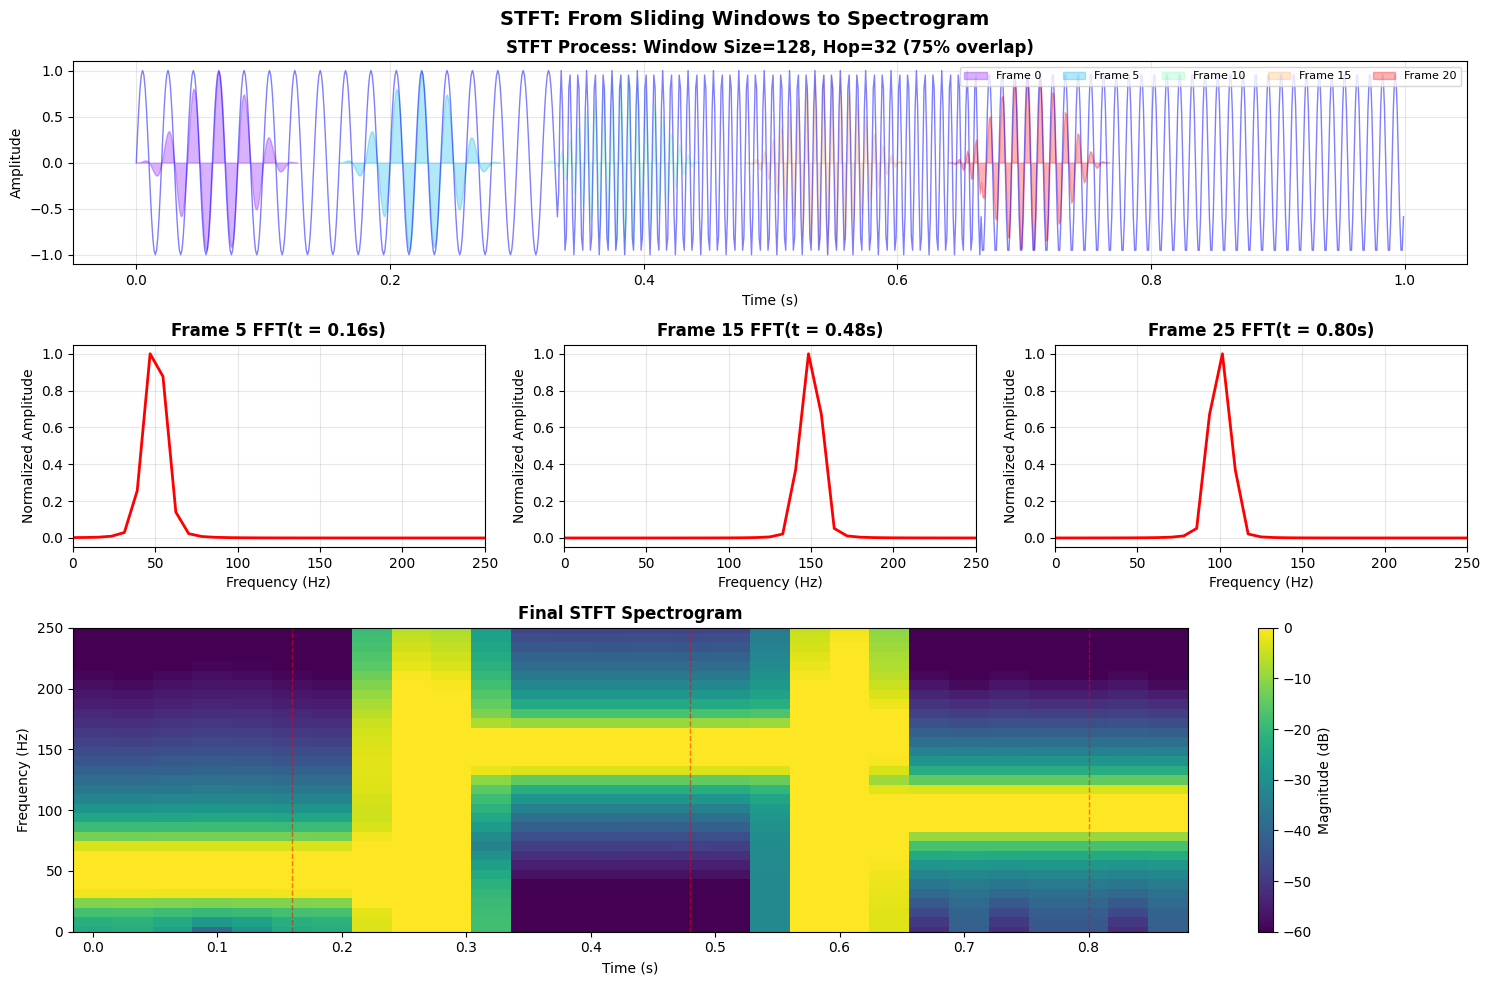

STFT Parameters:
• Window size: 128 samples (128.0 ms)
• Hop size: 32 samples (32.0 ms)
• Overlap: 75%
• Time resolution: 32.0 ms
• Frequency resolution: 7.8 Hz
• Total frames: 28


In [3]:
def manual_stft(signal_data, fs, window_size, hop_size, window_type='hann'):
    """Compute STFT manually to understand the process."""
    
    # Get window function
    if window_type == 'hann':
        window = np.hanning(window_size)
    else:
        window = np.ones(window_size)
    
    # Calculate number of frames
    num_frames = (len(signal_data) - window_size) // hop_size + 1
    
    # Pre-allocate output
    num_bins = window_size // 2 + 1
    stft_matrix = np.zeros((num_bins, num_frames), dtype=complex)
    
    # Process each frame
    for i in range(num_frames):
        start = i * hop_size
        frame = signal_data[start:start + window_size]
        
        # Apply window and compute FFT
        windowed_frame = frame * window
        stft_matrix[:, i] = np.fft.rfft(windowed_frame)
    
    # Create time and frequency axes
    times = np.arange(num_frames) * hop_size / fs
    freqs = np.fft.rfftfreq(window_size, 1/fs)
    
    return freqs, times, stft_matrix


def stft_process_visualization():
    """Visualize the STFT process step by step."""
    
    # Create a simple test signal
    fs = 1000
    t = np.arange(0, 1, 1/fs)
    signal_data = np.concatenate([
        np.sin(2 * np.pi * 50 * t[:333]),   # 50 Hz
        np.sin(2 * np.pi * 150 * t[333:667]), # 150 Hz  
        np.sin(2 * np.pi * 100 * t[667:])     # 100 Hz
    ])
    
    window_size = 128
    hop_size = 32
    overlap = (window_size - hop_size) / window_size * 100
    
    # Compute STFT
    freqs, times, stft_matrix = manual_stft(signal_data, fs, window_size, hop_size)
    
    # Visualize the process
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(3, 3, height_ratios=[1, 1, 1.5])
    
    # Show signal with sliding windows
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(t, signal_data, 'b-', alpha=0.5, linewidth=1)
    
    # Highlight a few windows
    colors = plt.cm.rainbow(np.linspace(0, 1, 5))
    for i, color in enumerate([0, 5, 10, 15, 20]):
        start = color * hop_size
        end = start + window_size
        if end <= len(signal_data):
            window_t = t[start:end]
            window_sig = signal_data[start:end]
            window_func = np.hanning(len(window_sig))
            
            ax1.fill_between(window_t, window_sig * window_func, 
                           alpha=0.3, color=colors[i], 
                           label=f'Frame {color}')
    
    ax1.set_title(f'STFT Process: Window Size={window_size}, Hop={hop_size} ({overlap:.0f}% overlap)',
                 fontweight='bold')
    ax1.set_xlabel('Time (s)')
    ax1.set_ylabel('Amplitude')
    ax1.legend(loc='upper right', ncol=5, fontsize=8)
    ax1.grid(True, alpha=0.3)
    
    # Show individual frame FFTs
    frame_indices = [5, 15, 25]
    for idx, frame_num in enumerate(frame_indices):
        ax = fig.add_subplot(gs[1, idx])
        
        if frame_num < stft_matrix.shape[1]:
            spectrum = np.abs(stft_matrix[:, frame_num])
            ax.plot(freqs, spectrum / np.max(spectrum), 'r-', linewidth=2)
            ax.set_title(f'Frame {frame_num} FFT(t = {times[frame_num]:.2f}s)', 
                       fontweight='bold')
            ax.set_xlabel('Frequency (Hz)')
            ax.set_ylabel('Normalized Amplitude')
            ax.set_xlim(0, 250)
            ax.grid(True, alpha=0.3)
    
    # Show final spectrogram
    ax3 = fig.add_subplot(gs[2, :])
    magnitude = np.abs(stft_matrix)
    im = ax3.pcolormesh(times, freqs, 20 * np.log10(magnitude + 1e-10),
                       shading='auto', cmap='viridis', vmin=-60, vmax=0)
    
    # Mark the example frames
    for frame_num in frame_indices:
        if frame_num < len(times):
            ax3.axvline(times[frame_num], color='red', linestyle='--', 
                      alpha=0.5, linewidth=1)
    
    ax3.set_title('Final STFT Spectrogram', fontweight='bold')
    ax3.set_xlabel('Time (s)')
    ax3.set_ylabel('Frequency (Hz)')
    ax3.set_ylim(0, 250)
    
    cbar = plt.colorbar(im, ax=ax3, label='Magnitude (dB)')
    
    plt.suptitle('STFT: From Sliding Windows to Spectrogram', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print(f"STFT Parameters:")
    print(f"• Window size: {window_size} samples ({window_size/fs*1000:.1f} ms)")
    print(f"• Hop size: {hop_size} samples ({hop_size/fs*1000:.1f} ms)")
    print(f"• Overlap: {overlap:.0f}%")
    print(f"• Time resolution: {hop_size/fs*1000:.1f} ms")
    print(f"• Frequency resolution: {fs/window_size:.1f} Hz")
    print(f"• Total frames: {stft_matrix.shape[1]}")

stft_process_visualization()

## Part 3: Choosing STFT Parameters

### The Three-Way Trade-off

STFT parameters involve a three-way trade-off:

1. **Time Resolution** ↔ **Frequency Resolution**
   - Larger window → Better frequency resolution, worse time resolution
   - Smaller window → Better time resolution, worse frequency resolution

2. **Time Resolution** ↔ **Computational Cost**
   - More overlap → Better time resolution, more computation
   - Less overlap → Worse time resolution, less computation

3. **Visual Quality** ↔ **Information Content**
   - High overlap → Smooth spectrogram, redundant information
   - Low overlap → Blocky spectrogram, independent frames

Let's explore these trade-offs interactively:

In [4]:
from ipywidgets import interact, IntSlider, FloatSlider
from scipy import signal

def stft_parameter_explorer(window_ms, overlap_percent, signal_type):
    """Interactive STFT parameter exploration."""
    
    fs = 4000
    duration = 2.0
    t = np.arange(0, duration, 1/fs)
    
    # Generate different test signals
    if signal_type == 'Chirp':
        sig = signal.chirp(t, f0=100, f1=1000, t1=duration, method='linear')
        description = "Linear chirp 100-1000 Hz"
    elif signal_type == 'Pulses':
        sig = np.zeros_like(t)
        pulse_times = [0.3, 0.7, 1.1, 1.5, 1.9]
        for pt in pulse_times:
            pulse = signal.gausspulse(t - pt, fc=500, bw=0.5)
            sig += pulse
        description = "Gaussian pulses at 500 Hz"
    elif signal_type == 'Music-like':
        # Simulate musical notes
        sig = np.zeros_like(t)
        notes = [(0, 0.4, 261.63),  # C4
                (0.4, 0.8, 293.66),  # D4
                (0.8, 1.2, 329.63),  # E4
                (1.2, 1.6, 349.23),  # F4
                (1.6, 2.0, 392.00)]  # G4
        for start, end, freq in notes:
            mask = (t >= start) & (t < end)
            sig[mask] = np.sin(2 * np.pi * freq * t[mask])
            # Add harmonics
            sig[mask] += 0.5 * np.sin(2 * np.pi * freq * 2 * t[mask])
            sig[mask] += 0.25 * np.sin(2 * np.pi * freq * 3 * t[mask])
        description = "Musical notes with harmonics"
    else:  # Speech-like
        # Simulate formant structure
        sig = signal.chirp(t, f0=100, f1=300, t1=1, method='linear')
        sig += 0.5 * signal.chirp(t, f0=800, f1=1200, t1=1, method='linear')
        sig[t > 1] = 0.3 * np.random.randn(len(t[t > 1]))
        description = "Speech-like formants"
    
    # Convert parameters
    window_size = int(window_ms * fs / 1000)
    window_size = max(64, min(window_size, len(sig)//2))  # Bounds
    hop_size = int(window_size * (1 - overlap_percent / 100))
    hop_size = max(1, hop_size)
    
    # Compute STFT
    f_spec, t_spec, Sxx = signal.spectrogram(sig, fs, 
                                            nperseg=window_size,
                                            noverlap=window_size - hop_size,
                                            window='hann')
    
    # Calculate metrics
    time_resolution = hop_size / fs * 1000  # ms
    freq_resolution = fs / window_size  # Hz
    num_frames = len(t_spec)
    computation_cost = num_frames * window_size * np.log2(window_size)  # Rough estimate
    
    # Create visualization
    fig = plt.figure(figsize=(15, 10))
    gs = fig.add_gridspec(3, 2, height_ratios=[1, 2, 1])
    
    # Signal
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(t, sig, 'b-', linewidth=0.5)
    ax1.set_title(f'Signal: {description}', fontweight='bold')
    ax1.set_ylabel('Amplitude')
    ax1.grid(True, alpha=0.3)
    
    # Spectrogram
    ax2 = fig.add_subplot(gs[1, :])
    im = ax2.pcolormesh(t_spec, f_spec, 10 * np.log10(Sxx + 1e-10),
                       shading='auto', cmap='viridis', vmin=-60, vmax=0)
    ax2.set_ylabel('Frequency (Hz)')
    ax2.set_xlabel('Time (s)')
    ax2.set_ylim(0, min(1500, fs/2))
    ax2.set_title(f'STFT Spectrogram', fontweight='bold')
    
    # Add grid to show resolution
    ax2.grid(True, alpha=0.2, which='both')
    
    # Colorbar
    cbar = plt.colorbar(im, ax=ax2, label='Power (dB)')
    
    # Metrics display
    ax3 = fig.add_subplot(gs[2, 0])
    ax3.axis('off')
    
    metrics_text = f"""
    STFT Parameters:
    • Window: {window_size} samples ({window_ms:.1f} ms)
    • Hop: {hop_size} samples ({hop_size/fs*1000:.1f} ms)
    • Overlap: {overlap_percent:.0f}%
    
    Resolution:
    • Time: {time_resolution:.1f} ms
    • Frequency: {freq_resolution:.1f} Hz
    • Frames: {num_frames}
    """
    ax3.text(0.1, 0.5, metrics_text, fontsize=10, family='monospace',
            verticalalignment='center',
            bbox=dict(boxstyle='round', facecolor='lightblue', alpha=0.8))
    
    # Trade-off visualization
    ax4 = fig.add_subplot(gs[2, 1])
    
    # Normalize metrics for radar plot
    # Trade-off visualization (polar radar)
    angles = np.linspace(0, 2*np.pi, 5, endpoint=True)  # 4 metrics + closing angle
    metrics = np.array([
        1 / (time_resolution + 1),          # better time res => larger
        1 / (freq_resolution + 1),          # better freq res => larger
        1 / (computation_cost / 1e6 + 1),   # lower cost => larger
        overlap_percent / 100.0             # visual quality proxy
    ])
    metrics = np.concatenate([metrics, [metrics[0]]])    # close polygon
    
    ax4 = fig.add_subplot(gs[2, 1], projection='polar')  # single polar axes
    ax4.plot(angles, metrics, 'b-', linewidth=2)
    ax4.fill(angles, metrics, 'blue', alpha=0.25)
    ax4.set_xticks(angles[:-1])
    ax4.set_xticklabels(['Time Res', 'Freq Res', 'Efficiency', 'Quality'])
    ax4.set_ylim(0, 1)
    ax4.set_title('Trade-off Analysis', fontweight='bold', pad=20)
    ax4.grid(True)

    
    plt.suptitle(f'STFT Parameter Explorer', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

from ipywidgets import Dropdown
interact(stft_parameter_explorer,
         window_ms=IntSlider(value=50, min=10, max=200, step=10, 
                           description='Window (ms)'),
         overlap_percent=IntSlider(value=75, min=0, max=95, step=5,
                                  description='Overlap (%)'),
         signal_type=Dropdown(options=['Chirp', 'Pulses', 'Music-like', 'Speech-like'],
                            value='Chirp', description='Signal Type'))

interactive(children=(IntSlider(value=50, description='Window (ms)', max=200, min=10, step=10), IntSlider(valu…

<function __main__.stft_parameter_explorer(window_ms, overlap_percent, signal_type)>

## Parameter Selection Guidelines

### By Application Domain

| Application | Window Size | Overlap | Reasoning |
|-------------|-------------|---------|-----------|  
| **Speech** | 20–40 ms | 50–75% | Phonemes last ~50 ms, pitch ~10 ms |
| **Music** | 50–100 ms | 75–90% | Notes need frequency precision |
| **Vibration** | 100–500 ms | 50–75% | Mechanical frequencies are stable |
| **Bioacoustics** | 5–50 ms | 80–90% | Animal calls have rapid modulation |
| **Radio/Radar** | 1–10 ms | 50–90% | Fast frequency hopping |
| **Seismic** | 1–10 s | 50–75% | Very low frequencies |
| **Ionosphere – Space Weather (SIDs, geomagnetic storms)** | 0.5–2.0 s | 50–75% | Requires fine spectral resolution to detect slow perturbations in VLF/ELF propagation |
| **Ionosphere – Meteor Detection (forward scatter trails)** | 10–50 ms | 75–90% | Transient bursts last milliseconds; high overlap ensures events aren’t missed |
| **Ionosphere – Lightning & Whistlers** | 20–200 ms | 75–90% | Broadband impulses with dispersive tails; balance of time/freq resolution needed |
| **Ionosphere – Auroral/Plasma Waves (chorus, hiss, AKR)** | 200 ms – 1 s | 80–90% | Fine frequency resolution required to resolve faint natural emissions |
| **Ionosphere – Rocket/Missile Effects** | 0.5–1.0 s | 50–75% | Similar to SIDs; track localized disturbances in ionospheric conductivity |

---

### By Signal Characteristics

**Transient events** (clicks, pops, impulses, meteors, lightning sferics)  
- Small window (good time resolution)  
- High overlap (don’t miss the event)  
- Example: **10–20 ms window, 90% overlap**

**Harmonic signals** (music, auroral chorus emissions)  
- Large window (resolve harmonics clearly)  
- Moderate overlap  
- Example: **200–500 ms window, 75% overlap**

**Broadband noise** (wind, thermal noise, background ionospheric hiss)  
- Medium window  
- Low overlap (independent noise estimates)  
- Example: **100 ms window, 50% overlap**

---

> **Note:** In ionospheric applications, FFT/STFT parameter choices trend toward **larger window sizes with high overlap** to maximize spectral resolution while still capturing transient events. This heavy computational demand underlines why **GPU acceleration is essential for Ionosense real-time pipelines**.


## Part 4: Advanced Spectrogram Visualization

### Making Beautiful and Informative Spectrograms

A good spectrogram is both scientifically accurate and visually clear. Let's explore advanced visualization techniques:

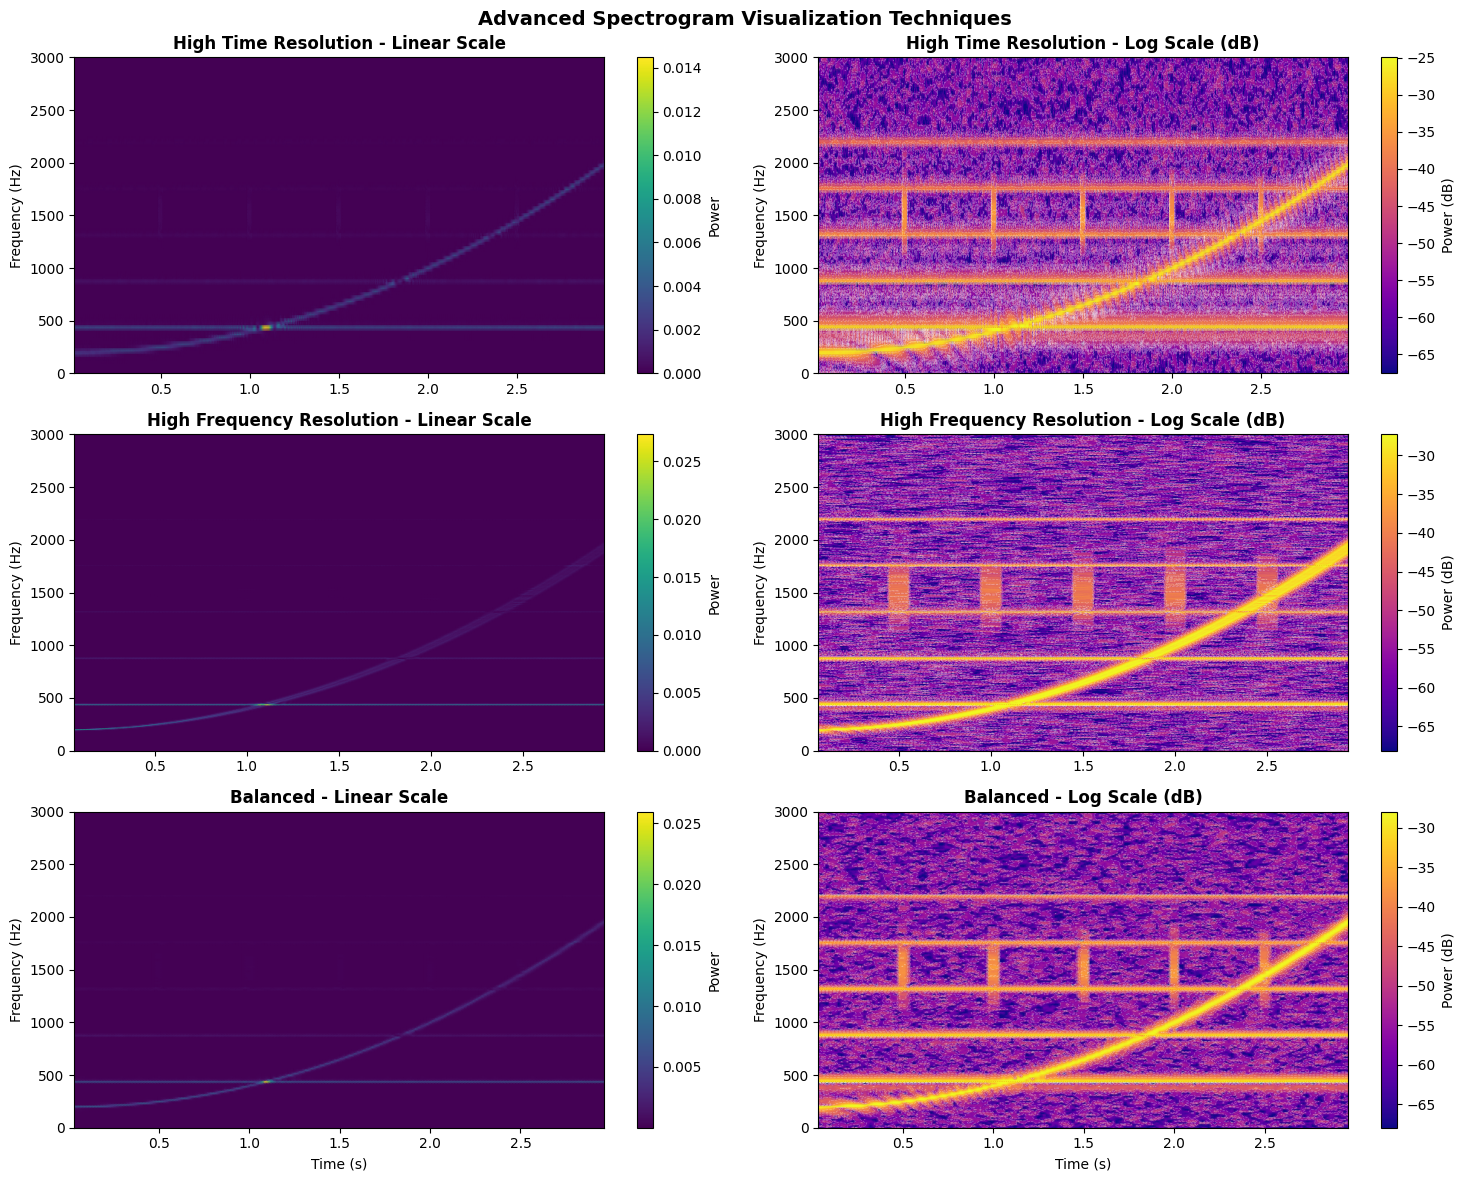

Visualization Tips:
• Linear scale: Good for strong, isolated components
• Log scale (dB): Reveals weak signals and noise floor
• Dynamic range: Use percentiles, not min/max
• Contours: Help identify ridges and patterns
• Color maps: 'viridis' for science, 'plasma' for presentation


In [5]:
def advanced_spectrogram_visualization():
    """Demonstrate advanced spectrogram visualization techniques."""
    
    # Generate a complex test signal
    fs = 8000
    duration = 3.0
    t = np.arange(0, duration, 1/fs)
    
    # Build a rich signal
    sig = np.zeros_like(t)
    
    # Add frequency sweep
    sig += 0.5 * signal.chirp(t, f0=200, f1=2000, t1=duration, method='quadratic')
    
    # Add harmonics
    fundamental = 440  # A4
    for harmonic in range(1, 6):
        sig += (0.5 / harmonic) * np.sin(2 * np.pi * fundamental * harmonic * t)
    
    # Add pulses
    for pulse_time in [0.5, 1.0, 1.5, 2.0, 2.5]:
        sig += 2 * signal.gausspulse(t - pulse_time, fc=1500, bw=0.3)
    
    # Add noise
    sig += 0.1 * np.random.randn(len(t))
    
    # Compute spectrograms with different parameters
    params = [
        {'nperseg': 256, 'noverlap': 240, 'name': 'High Time Resolution'},
        {'nperseg': 1024, 'noverlap': 960, 'name': 'High Frequency Resolution'},
        {'nperseg': 512, 'noverlap': 384, 'name': 'Balanced'}
    ]
    
    fig, axes = plt.subplots(3, 2, figsize=(15, 12))
    
    for idx, param in enumerate(params):
        # Compute spectrogram
        f_spec, t_spec, Sxx = signal.spectrogram(sig, fs, **{k: v for k, v in param.items() if k != 'name'})
        
        # Linear scale
        ax_lin = axes[idx, 0]
        im_lin = ax_lin.pcolormesh(t_spec, f_spec, Sxx, 
                                   shading='gouraud', cmap='viridis')
        ax_lin.set_title(f'{param["name"]} - Linear Scale', fontweight='bold')
        ax_lin.set_ylabel('Frequency (Hz)')
        ax_lin.set_ylim(0, 3000)
        plt.colorbar(im_lin, ax=ax_lin, label='Power')
        
        # Log scale (dB)
        ax_log = axes[idx, 1]
        Sxx_db = 10 * np.log10(Sxx + 1e-10)
        
        # Apply dynamic range compression
        vmin = np.percentile(Sxx_db, 5)
        vmax = np.percentile(Sxx_db, 99)
        
        im_log = ax_log.pcolormesh(t_spec, f_spec, Sxx_db,
                                   shading='gouraud', cmap='plasma',
                                   vmin=vmin, vmax=vmax)
        ax_log.set_title(f'{param["name"]} - Log Scale (dB)', fontweight='bold')
        ax_log.set_ylabel('Frequency (Hz)')
        ax_log.set_ylim(0, 3000)
        
        # Add contour lines for clarity
        contour_levels = np.linspace(vmin + 10, vmax - 10, 5)
        ax_log.contour(t_spec, f_spec, Sxx_db, levels=contour_levels,
                      colors='white', alpha=0.3, linewidths=0.5)
        
        plt.colorbar(im_log, ax=ax_log, label='Power (dB)')
        
        # Add annotations
        if idx == 2:
            ax_lin.set_xlabel('Time (s)')
            ax_log.set_xlabel('Time (s)')
        
        # Mark harmonics
        for h in range(1, 6):
            ax_log.axhline(440 * h, color='red', linestyle=':', 
                         alpha=0.3, linewidth=0.5)
    
    plt.suptitle('Advanced Spectrogram Visualization Techniques', 
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("Visualization Tips:")
    print("• Linear scale: Good for strong, isolated components")
    print("• Log scale (dB): Reveals weak signals and noise floor")
    print("• Dynamic range: Use percentiles, not min/max")
    print("• Contours: Help identify ridges and patterns")
    print("• Color maps: 'viridis' for science, 'plasma' for presentation")

advanced_spectrogram_visualization()

## Part 5: STFT Reconstruction and COLA

### The Inverse STFT

An important property of the STFT is that it's invertible - you can reconstruct the original signal from the spectrogram. This requires the **Constant Overlap-Add (COLA)** condition:

$$sum_{m} w(n - mH) = c$$

Where $w$ is the window, $H$ is the hop size, and $c$ is a constant.

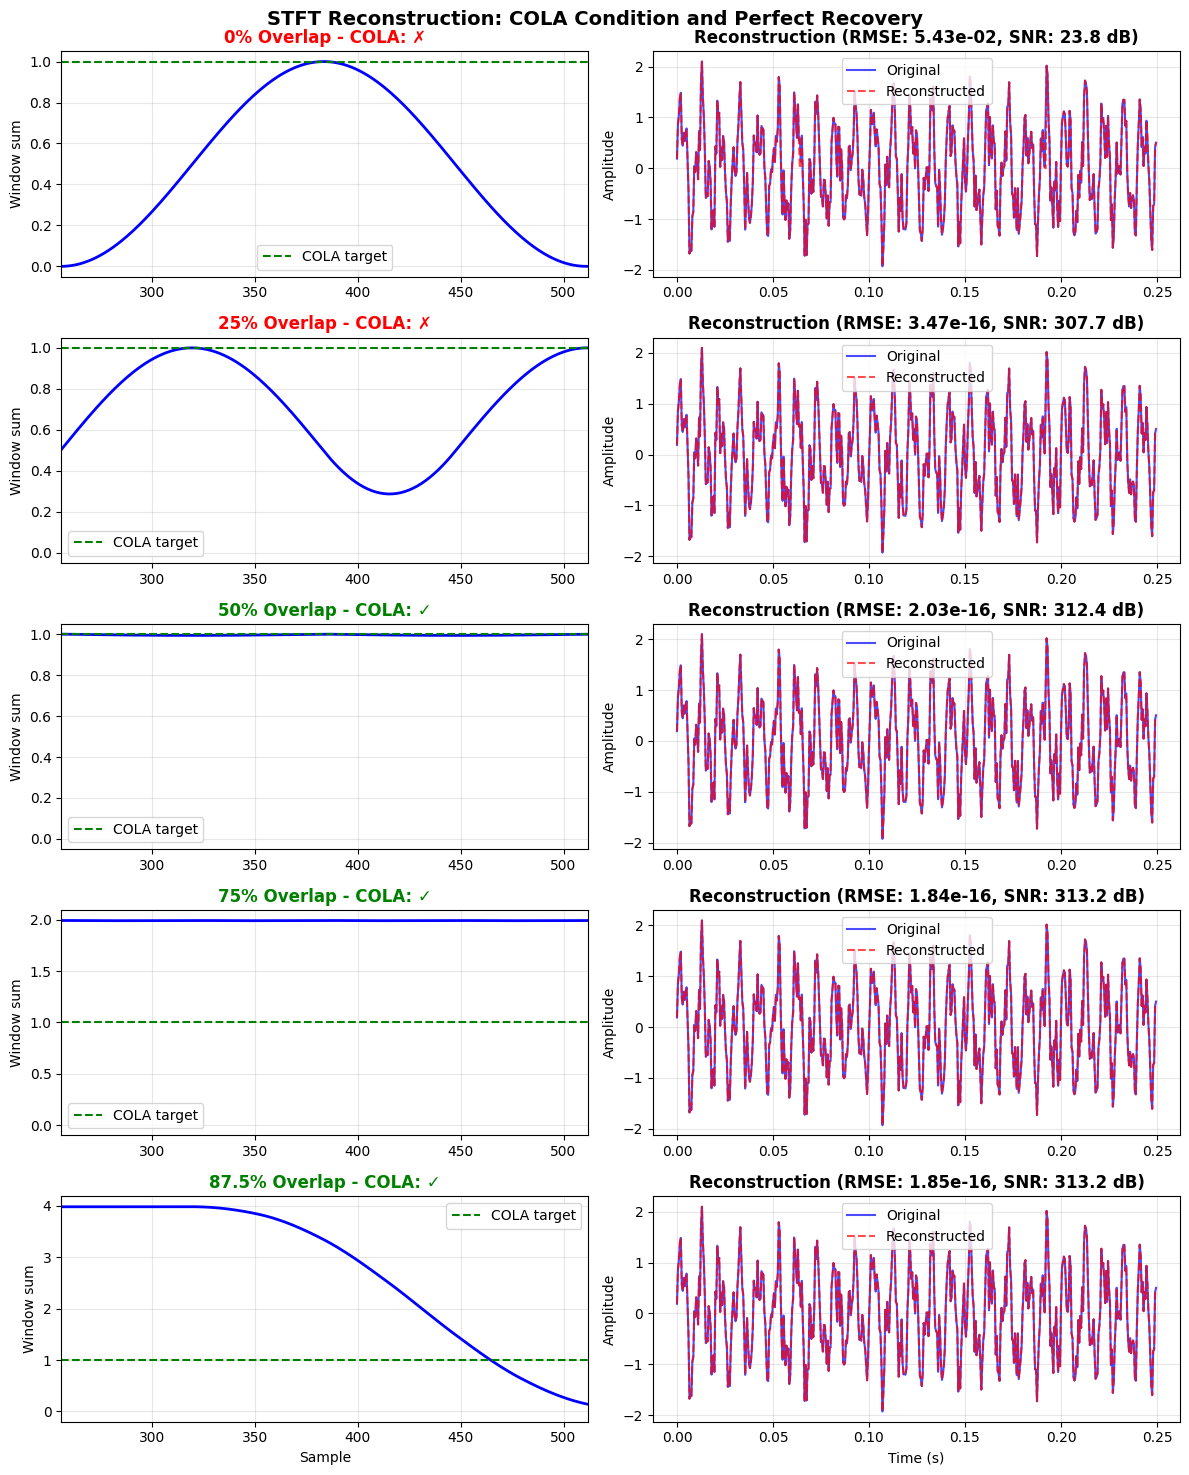

COLA Requirements for Common Windows:
• Hann: 50% overlap (standard choice)
• Hamming: 50% or 75% overlap
• Blackman: 66% overlap
• Rectangular: Any overlap (but don't use rectangular!)


In [6]:
def stft_reconstruction_demo():
    """Demonstrate STFT reconstruction and COLA condition."""
    
    # Generate test signal
    fs = 2000
    t = np.arange(0, 1, 1/fs)
    original = (np.sin(2 * np.pi * 100 * t) + 
               0.5 * np.sin(2 * np.pi * 250 * t) + 
               0.3 * np.random.randn(len(t)))
    
    # Test different overlap percentages
    overlaps = [0, 25, 50, 75, 87.5]
    window_size = 256
    
    fig, axes = plt.subplots(len(overlaps), 2, figsize=(12, 15))
    
    for idx, overlap_percent in enumerate(overlaps):
        # Calculate hop
        hop = int(window_size * (1 - overlap_percent/100))
        
        # Forward STFT
        f, t_stft, Zxx = signal.stft(original, fs, nperseg=window_size, 
                                     noverlap=window_size - hop, 
                                     window='hann')
        
        # Inverse STFT
        _, reconstructed = signal.istft(Zxx, fs, nperseg=window_size,
                                       noverlap=window_size - hop,
                                       window='hann')
        
        # Ensure same length
        min_len = min(len(original), len(reconstructed))
        original_trim = original[:min_len]
        reconstructed_trim = reconstructed[:min_len]
        
        # Calculate error
        error = original_trim - reconstructed_trim
        rmse = np.sqrt(np.mean(error**2))
        snr = 20 * np.log10(np.sqrt(np.mean(original_trim**2)) / rmse) if rmse > 0 else np.inf
        
        # Check COLA
        window = np.hanning(window_size)
        cola_sum = np.zeros(window_size * 3)
        for i in range(10):
            start = i * hop
            if start + window_size <= len(cola_sum):
                cola_sum[start:start + window_size] += window
        
        # Check if COLA is satisfied (constant sum)
        cola_constant = cola_sum[window_size:window_size + hop]
        cola_satisfied = np.allclose(cola_constant, cola_constant[0], rtol=0.01)
        
        # Plot COLA visualization
        ax1 = axes[idx, 0]
        x_cola = np.arange(len(cola_sum))
        ax1.plot(x_cola, cola_sum, 'b-', linewidth=2)
        ax1.axhline(1.0, color='green', linestyle='--', label='COLA target')
        ax1.set_title(f'{overlap_percent}% Overlap - COLA: {"✓" if cola_satisfied else "✗"}',
                     fontweight='bold', 
                     color='green' if cola_satisfied else 'red')
        ax1.set_ylabel('Window sum')
        ax1.set_xlim(window_size, window_size * 2)
        ax1.grid(True, alpha=0.3)
        ax1.legend()
        
        # Plot reconstruction error
        ax2 = axes[idx, 1]
        time_trim = t[:min_len]
        ax2.plot(time_trim[:500], original_trim[:500], 'b-', 
                alpha=0.7, label='Original')
        ax2.plot(time_trim[:500], reconstructed_trim[:500], 'r--', 
                alpha=0.7, label='Reconstructed')
        ax2.set_title(f'Reconstruction (RMSE: {rmse:.2e}, SNR: {snr:.1f} dB)',
                     fontweight='bold')
        ax2.set_ylabel('Amplitude')
        ax2.grid(True, alpha=0.3)
        ax2.legend()
        
        if idx == len(overlaps) - 1:
            ax1.set_xlabel('Sample')
            ax2.set_xlabel('Time (s)')
    
    plt.suptitle('STFT Reconstruction: COLA Condition and Perfect Recovery',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()
    
    print("COLA Requirements for Common Windows:")
    print("• Hann: 50% overlap (standard choice)")
    print("• Hamming: 50% or 75% overlap")
    print("• Blackman: 66% overlap")
    print("• Rectangular: Any overlap (but don't use rectangular!)")

stft_reconstruction_demo()

## STFT with GPU Processing

The `ionosense_hpc` ResearchEngine doesn't provide built-in STFT, but you can implement it by processing frames sequentially:

In [7]:
try:
    from ionosense_hpc.core import ResearchEngine, EngineConfig
    
    def gpu_stft_demo():
        """Implement STFT using GPU engine."""
        
        # Generate test signal
        fs = 1000
        duration = 2.0
        t = np.arange(0, duration, 1/fs)
        
        # Varying frequency content
        sig = np.concatenate([
            np.sin(2 * np.pi * 50 * t[:500]),
            np.sin(2 * np.pi * 150 * t[500:1000]),
            np.sin(2 * np.pi * 100 * t[1000:1500]),
            np.sin(2 * np.pi * 200 * t[1500:])
        ]).astype(np.float32)
        
        # STFT parameters
        window_size = 256
        hop_size = 64
        
        # Initialize GPU engine
        config = EngineConfig()
        config.nfft = window_size
        config.batch = 1
        config.sample_rate_hz = fs
        
        engine = ResearchEngine()
        engine.initialize(config)
        
        # Process frames
        num_frames = (len(sig) - window_size) // hop_size + 1
        stft_magnitude = []
        
        import time
        start_time = time.time()
        
        for i in range(num_frames):
            frame = sig[i * hop_size : i * hop_size + window_size]
            if len(frame) == window_size:
                magnitude = engine.process(frame)[0]
                stft_magnitude.append(magnitude)
        
        gpu_time = time.time() - start_time
        
        # Convert to array
        stft_magnitude = np.array(stft_magnitude).T
        
        # Compare with CPU STFT
        start_time = time.time()
        f_cpu, t_cpu, Sxx_cpu = signal.spectrogram(sig, fs, 
                                                   nperseg=window_size,
                                                   noverlap=window_size - hop_size)
        cpu_time = time.time() - start_time
        
        # Visualize
        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        
        # GPU result
        times = np.arange(stft_magnitude.shape[1]) * hop_size / fs
        freqs = np.fft.rfftfreq(window_size, 1/fs)
        
        axes[0].pcolormesh(times, freqs, 
                          20 * np.log10(stft_magnitude + 1e-10),
                          shading='auto', cmap='viridis')
        axes[0].set_title(f'GPU STFT (Time: {gpu_time:.3f}s)', fontweight='bold')
        axes[0].set_xlabel('Time (s)')
        axes[0].set_ylabel('Frequency (Hz)')
        axes[0].set_ylim(0, 300)
        
        # CPU result
        axes[1].pcolormesh(t_cpu, f_cpu,
                          10 * np.log10(Sxx_cpu + 1e-10),
                          shading='auto', cmap='viridis')
        axes[1].set_title(f'CPU STFT (Time: {cpu_time:.3f}s)', fontweight='bold')
        axes[1].set_xlabel('Time (s)')
        axes[1].set_ylabel('Frequency (Hz)')
        axes[1].set_ylim(0, 300)
        
        plt.suptitle(f'GPU vs CPU STFT (Speedup: {cpu_time/gpu_time:.1f}x)',
                    fontsize=14, fontweight='bold')
        plt.tight_layout()
        plt.show()
        
        print(f"Processing {num_frames} frames:")
        print(f"GPU: {gpu_time:.3f}s ({num_frames/gpu_time:.0f} frames/sec)")
        print(f"CPU: {cpu_time:.3f}s ({num_frames/cpu_time:.0f} frames/sec)")
    
    gpu_stft_demo()
    
except ImportError:
    print("GPU ResearchEngine not available.")
    print("To implement GPU STFT:")
    print("1. Initialize engine with desired window size")
    print("2. Loop through signal with chosen hop size")
    print("3. Process each frame with engine.process()")
    print("4. Stack results into spectrogram matrix")

Ionosense-HPC v0.9.0 ready.
GPU ResearchEngine not available.
To implement GPU STFT:
1. Initialize engine with desired window size
2. Loop through signal with chosen hop size
3. Process each frame with engine.process()
4. Stack results into spectrogram matrix


## Module Summary

### Key Concepts

1. **Non-stationary signals** require time-frequency analysis, not just frequency
2. **STFT** slides a window across the signal, computing FFT of each frame
3. **Three-way trade-off**: time resolution ↔ frequency resolution ↔ computation
4. **Overlap** smooths the spectrogram and improves time resolution
5. **COLA condition** enables perfect reconstruction from STFT

### Quick Reference

```python
# Standard STFT with scipy
f, t, Zxx = signal.stft(x, fs=sample_rate, 
                        nperseg=window_size,
                        noverlap=overlap_samples,
                        window='hann')

# Convert to spectrogram
Sxx = np.abs(Zxx)**2  # Power spectrogram
Sxx_db = 10 * np.log10(Sxx + 1e-10)  # In dB

# Inverse STFT
t, x_reconstructed = signal.istft(Zxx, fs=sample_rate)

# Key parameters
time_resolution = hop_size / sample_rate
freq_resolution = sample_rate / window_size
num_frames = (signal_length - window_size) // hop_size + 1
```

### Parameter Selection Checklist

✓ What's the fastest change in your signal? → Sets maximum window size
✓ What frequency resolution do you need? → Sets minimum window size  
✓ Real-time or offline processing? → Affects overlap percentage
✓ Visual quality important? → Use 75-90% overlap
✓ Need reconstruction? → Ensure COLA (50% overlap with Hann)

### What's Next?

In Module 5, we'll learn how to extract and analyze the information in spectrograms: detecting peaks, measuring SNR, tracking frequencies over time, and building automated analysis systems.